<a href="https://colab.research.google.com/github/srishti-bs/Statistical-Foundations-of-Data-Science/blob/main/BiasVarianceTradeoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OLS Train MSE: 2.7369289391099776
OLS Test MSE: 4.0486410950642355


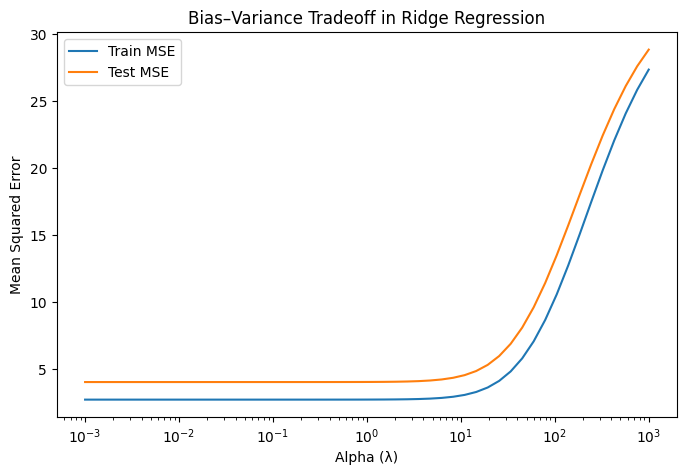

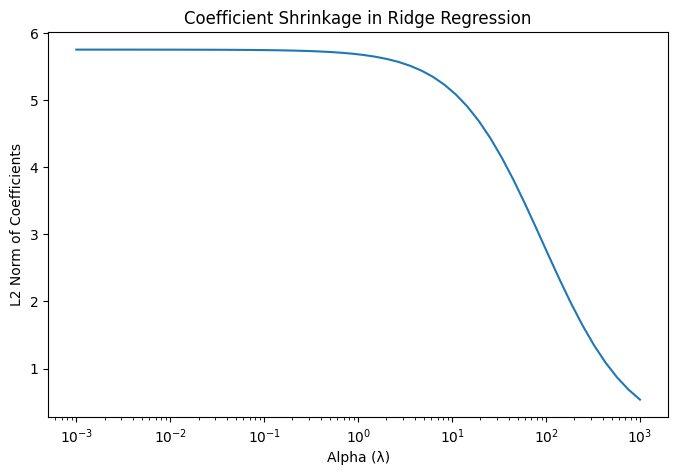

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Step 1: Generate data with multicollinearity
np.random.seed(42)
n = 150
p = 20
X = np.random.randn(n, p)
# Introduce multicollinearity
# Original: X[:, 5:] = X[:, :5] + np.random.normal(0, 0.1, (n, p‐5))
 # Fix: Tile X[:, :5] to match the dimension of X[:, 5:] before adding noise X[:, 5:] = np.tile(X[:, :5], (1, (p‐5)//5)) + np.random.normal(0, 0.1, (n, p‐5))
beta_true = np.random.randn(p)
y = X @ beta_true + np.random.normal(0, 2, n)
# Step 2: Train‐test split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3,
random_state=42
)
# Step 3: Standardize predictors
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Step 4: OLS regression
ols = LinearRegression()
ols.fit(X_train, y_train)
y_train_pred_ols = ols.predict(X_train)
y_test_pred_ols = ols.predict(X_test)
ols_train_mse = mean_squared_error(y_train, y_train_pred_ols)
ols_test_mse = mean_squared_error(y_test, y_test_pred_ols)
print("OLS Train MSE:", ols_train_mse)
print("OLS Test MSE:", ols_test_mse)
# Step 5: Ridge regression for different alpha values
alphas = np.logspace(-3, 3, 50)
train_mse = []
test_mse = []
coef_norm = []
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    y_train_pred = ridge.predict(X_train)
    y_test_pred = ridge.predict(X_test)
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))
    coef_norm.append(np.linalg.norm(ridge.coef_))
# Step 6: Plot Bias–Variance Tradeoff (MSE vs Alpha)
plt.figure(figsize=(8, 5))
plt.semilogx(alphas, train_mse, label="Train MSE")
plt.semilogx(alphas, test_mse, label="Test MSE")
plt.xlabel("Alpha (λ)")
plt.ylabel("Mean Squared Error")
plt.title("Bias–Variance Tradeoff in Ridge Regression")
plt.legend()
plt.show()
# Step 7: Plot Coefficient Shrinkage
plt.figure(figsize=(8, 5))
plt.semilogx(alphas, coef_norm)
plt.xlabel("Alpha (λ)")
plt.ylabel("L2 Norm of Coefficients")
plt.title("Coefficient Shrinkage in Ridge Regression")
plt.show()